<a href="https://colab.research.google.com/github/sarwathasan72-svg/Masai_IIT_AIML/blob/main/Workshop_2_Aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Loan Application --> approved, reject --> classification problem

# Features:
# age
# occupation
# salary
# credit score / cibil score
# existing loans/libalities
# dependents

# target --> approved: Yes, No



In [ ]:
# Regression Problem: predicting a continuous value
# eg: house price prediction

# Features:
# location
# sqft area
# bhk
# floor
# aminities


# outcome:
# Price:

In [ ]:
import pandas as pd
import numpy as np

# For reproducibility
np.random.seed(42)

# Number of records
n = 5000

# -----------------------------
# Generate Features
# -----------------------------

age = np.random.randint(21, 61, n)

income = np.random.randint(20000, 150001, n)

loan_amount = np.random.randint(50000, 1000001, n)

credit_score = np.random.randint(300, 851, n)

employment = np.random.choice(
    ["Salaried", "Self-Employed"],
    size=n,
    p=[0.7, 0.3]
)

existing_loans = np.random.randint(0, 6, n)

property_area = np.random.choice(
    ["Urban", "Semiurban", "Rural"],
    size=n,
    p=[0.5, 0.3, 0.2]
)

# -----------------------------
# Loan Approval Logic
# -----------------------------

approval_score = np.zeros(n)

# Credit Score Contribution
approval_score += np.where(credit_score >= 750, 4, 0)
approval_score += np.where((credit_score >= 650) & (credit_score < 750), 2, 0)
approval_score += np.where((credit_score >= 550) & (credit_score < 650), 1, 0)

# Income Contribution
approval_score += np.where(income >= 100000, 3, 0)
approval_score += np.where((income >= 60000) & (income < 100000), 2, 0)
approval_score += np.where((income >= 40000) & (income < 60000), 1, 0)

# Loan Amount Penalty
approval_score -= np.where(loan_amount > 700000, 2, 0)
approval_score -= np.where(loan_amount > 900000, 1, 0)

# Existing Loans Penalty
approval_score -= existing_loans

# Employment Bonus
approval_score += np.where(employment == "Salaried", 1, 0)

# Property Area Bonus
approval_score += np.where(property_area == "Urban", 1, 0)

# Small Random Noise
approval_score += np.random.normal(0, 0.8, n)

# Final Approval
approved = np.where(approval_score >= 4, 1, 0)

# -----------------------------
# Create DataFrame
# -----------------------------

loan_df = pd.DataFrame({
    "Age": age,
    "Income": income,
    "LoanAmount": loan_amount,
    "CreditScore": credit_score,
    "Employment": employment,
    "ExistingLoans": existing_loans,
    "PropertyArea": property_area,
    "Approved": approved
})

# -----------------------------
# Add Some Missing Values
# -----------------------------

for col in ["Income", "LoanAmount"]:
    loan_df.loc[
        loan_df.sample(frac=0.02, random_state=42).index,
        col
    ] = np.nan

# -----------------------------
# Save Dataset
# -----------------------------

loan_df.to_csv("loan_data.csv", index=False)

print("Dataset Created Successfully!")
print()

print(loan_df.head())

print("\nShape:", loan_df.shape)

print("\nLoan Approval Distribution")
print(loan_df["Approved"].value_counts())

Dataset Created Successfully!

   Age   Income  LoanAmount  CreditScore Employment  ExistingLoans  \
0   59  73865.0    581149.0          838   Salaried              5   
1   49  66686.0    288366.0          390   Salaried              3   
2   35  95910.0    374058.0          571   Salaried              1   
3   28  24675.0    113888.0          304   Salaried              3   
4   41  86706.0    915718.0          518   Salaried              2   

  PropertyArea  Approved  
0        Urban         0  
1    Semiurban         0  
2        Urban         1  
3        Urban         0  
4        Urban         0  

Shape: (5000, 8)

Loan Approval Distribution
Approved
0    4172
1     828
Name: count, dtype: int64


In [ ]:
loan_df

,Age,Income,LoanAmount,CreditScore,Employment,ExistingLoans,PropertyArea,Approved
0,59,73865.0,581149.0,838,Salaried,5,Urban,0
1,49,66686.0,288366.0,390,Salaried,3,Semiurban,0
2,35,95910.0,374058.0,571,Salaried,1,Urban,1
3,28,24675.0,113888.0,304,Salaried,3,Urban,0
4,41,86706.0,915718.0,518,Salaried,2,Urban,0
...,...,...,...,...,...,...,...,...
4995,24,93664.0,419591.0,461,Salaried,1,Semiurban,0
4996,49,70227.0,514702.0,729,Salaried,4,Rural,0
4997,54,52450.0,116896.0,368,Salaried,2,Semiurban,0
4998,33,104433.0,153431.0,432,Self-Employed,0,Rural,0


In [ ]:
loan_df.head()

,Age,Income,LoanAmount,CreditScore,Employment,ExistingLoans,PropertyArea,Approved
0,59,73865.0,581149.0,838,Salaried,5,Urban,0
1,49,66686.0,288366.0,390,Salaried,3,Semiurban,0
2,35,95910.0,374058.0,571,Salaried,1,Urban,1
3,28,24675.0,113888.0,304,Salaried,3,Urban,0
4,41,86706.0,915718.0,518,Salaried,2,Urban,0


In [ ]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            5000 non-null   int64  
 1   Income         4900 non-null   float64
 2   LoanAmount     4900 non-null   float64
 3   CreditScore    5000 non-null   int64  
 4   Employment     5000 non-null   object 
 5   ExistingLoans  5000 non-null   int64  
 6   PropertyArea   5000 non-null   object 
 7   Approved       5000 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 312.6+ KB


In [ ]:
loan_df.shape

(5000, 8)

In [ ]:
loan_df.describe()

,Age,Income,LoanAmount,CreditScore,ExistingLoans,Approved
count,5000.000000,4900.000000,4900.000000,5000.000000,5000.000000,5000.000000
mean,40.726200,84753.994490,527378.286327,571.192000,2.538000,0.165600
std,11.506299,37702.483081,274964.300201,159.143485,1.698568,0.371758
min,21.000000,20028.000000,50037.000000,300.000000,0.000000,0.000000
25%,31.000000,51206.250000,291413.500000,433.000000,1.000000,0.000000
50%,41.000000,85509.500000,533474.000000,568.000000,3.000000,0.000000
75%,51.000000,118232.500000,768764.750000,707.250000,4.000000,0.000000
max,60.000000,150000.000000,999500.000000,850.000000,5.000000,1.000000


In [ ]:
loan_df["PropertyArea"]

,PropertyArea
0,Urban
1,Semiurban
2,Urban
3,Urban
4,Urban
...,...
4995,Semiurban
4996,Rural
4997,Semiurban
4998,Rural


In [ ]:
loan_df["PropertyArea"].value_counts()

,count
PropertyArea,
Urban,2469
Semiurban,1521
Rural,1010


In [ ]:
loan_df["PropertyArea"].value_counts(normalize = True)

,proportion
PropertyArea,
Urban,0.4938
Semiurban,0.3042
Rural,0.2020


In [ ]:
loan_df["PropertyArea"].value_counts(normalize = True)*100

,proportion
PropertyArea,
Urban,49.38
Semiurban,30.42
Rural,20.20


In [ ]:
loan_df.isnull()

,Age,Income,LoanAmount,CreditScore,Employment,ExistingLoans,PropertyArea,Approved
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False


In [ ]:
loan_df.isnull().sum()

,0
Age,0
Income,100
LoanAmount,100
CreditScore,0
Employment,0
ExistingLoans,0
PropertyArea,0
Approved,0


In [ ]:
# dealing with missing data:
# 1. drop
# 2. fill --> fill the missing data



In [ ]:
loan_df.fillna(loan_df.mean(numeric_only = True), inplace = True)

In [ ]:
loan_df.isnull().sum()

,0
Age,0
Income,100
LoanAmount,100
CreditScore,0
Employment,0
ExistingLoans,0
PropertyArea,0
Approved,0


In [ ]:
loan_df["Approved"].value_counts()

,count
Approved,
0,4172
1,828


<Axes: xlabel='PropertyArea', ylabel='count'>

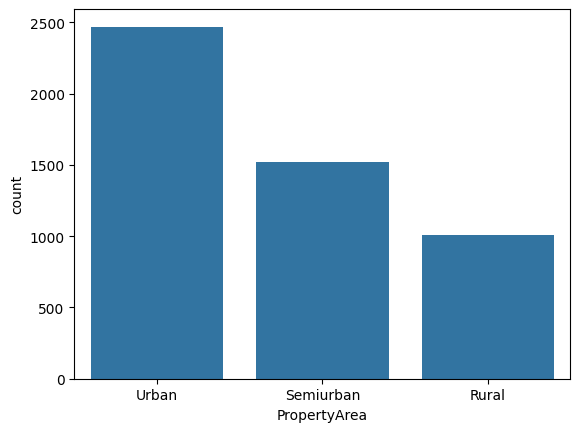

In [ ]:
import seaborn as sns
sns.countplot(x = "PropertyArea", data = loan_df)

In [ ]:
sns.countplot(x = "Approved", data = loan_df)

#Logistic Regression

In [ ]:
# instead of predicting yes/no, it will output the probability of approval:
# eg: output is 0.92 --> means 92% chance of the loan getting approved.

In [ ]:
loan_df.head()

,Age,Income,LoanAmount,CreditScore,Employment,ExistingLoans,PropertyArea,Approved
0,59,73865.0,581149.0,838,Salaried,5,Urban,0
1,49,66686.0,288366.0,390,Salaried,3,Semiurban,0
2,35,95910.0,374058.0,571,Salaried,1,Urban,1
3,28,24675.0,113888.0,304,Salaried,3,Urban,0
4,41,86706.0,915718.0,518,Salaried,2,Urban,0


In [ ]:
loan_df[["Age", "Income"]]

,Age,Income
0,59,73865.0
1,49,66686.0
2,35,95910.0
3,28,24675.0
4,41,86706.0
...,...,...
4995,24,93664.0
4996,49,70227.0
4997,54,52450.0
4998,33,104433.0


In [ ]:
x = loan_df.drop("Approved", axis = 1)
y = loan_df["Approved"]



In [ ]:
x

,Age,Income,LoanAmount,CreditScore,Employment,ExistingLoans,PropertyArea
0,59,73865.0,581149.0,838,Salaried,5,Urban
1,49,66686.0,288366.0,390,Salaried,3,Semiurban
2,35,95910.0,374058.0,571,Salaried,1,Urban
3,28,24675.0,113888.0,304,Salaried,3,Urban
4,41,86706.0,915718.0,518,Salaried,2,Urban
...,...,...,...,...,...,...,...
4995,24,93664.0,419591.0,461,Salaried,1,Semiurban
4996,49,70227.0,514702.0,729,Salaried,4,Rural
4997,54,52450.0,116896.0,368,Salaried,2,Semiurban
4998,33,104433.0,153431.0,432,Self-Employed,0,Rural


In [ ]:
y

,Approved
0,0
1,0
2,1
3,0
4,0
...,...
4995,0
4996,0
4997,0
4998,0


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)




In [ ]:
x_train.shape

(4000, 7)

In [ ]:
5000*0.8

4000.0

In [ ]:
y_train.shape

(4000,)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)


In [ ]:
x_train.head()

,Age,Income,LoanAmount,CreditScore,Employment,ExistingLoans,PropertyArea
3661,28,129979.0,749338.0,370,Self-Employed,3,Urban
4316,40,87863.0,756443.0,660,Salaried,1,Semiurban
2300,41,48742.0,650139.0,415,Salaried,2,Semiurban
389,23,93369.0,634436.0,575,Salaried,2,Rural
4453,32,114830.0,500067.0,476,Self-Employed,4,Rural


In [ ]:
# 4906, 1002

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 40)



In [ ]:
x_train.head()

,Age,Income,LoanAmount,CreditScore,Employment,ExistingLoans,PropertyArea
2218,55,116621.0,685589.0,408,Self-Employed,4,Urban
1708,22,106442.0,636864.0,399,Salaried,3,Urban
2456,38,75501.0,98591.0,568,Salaried,2,Semiurban
4371,31,142762.0,972334.0,608,Salaried,1,Urban
3474,51,65929.0,174078.0,558,Salaried,5,Urban


In [ ]:
x_train.drop(["Employment", "PropertyArea"], axis = 1, inplace = True)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
x_test.drop(["Employment", "PropertyArea"], axis = 1, inplace = True)


In [ ]:
predictions = model.predict(x_test)
type(predictions)

numpy.ndarray

In [ ]:
print(predictions[:15])

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]


#Decision Tree

In [ ]:
credit_score > 75%
      /  \Reject
    Income > 50k
    / \
Approve Reject


In [ ]:
#Advantages of Decision trees:
# 1. Easy to understand
# 2. Calculation is easy and not too much mathematical
# 3. Explainable AI

In [ ]:
from sklearn.tree  import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth = 4, random_state = 30)
tree.fit(x_train, y_train)

pred = tree.predict(x_test)


In [ ]:
print(pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1]


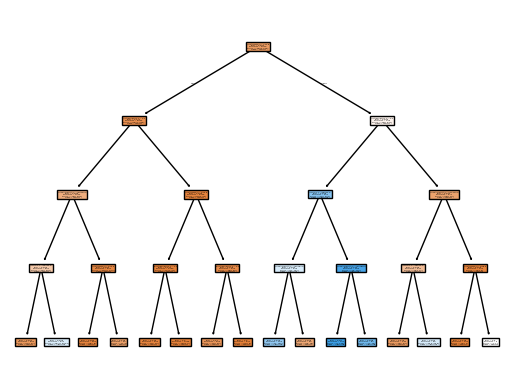

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(
    tree,
    filled = True,
    feature_names= x_train.columns,
    class_names = ["Reject", "Approve"]
)

plt.show()